In [1]:
import os 
from dotenv import load_dotenv

In [7]:
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, AnyMessage

In [8]:
env_path = r"D:\common_credentials\.env"
load_dotenv(dotenv_path=env_path)

True

In [9]:
llm= ChatGroq(model='llama-3.1-8b-instant')

In [10]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

llm_with_tools=llm.bind_tools(tools)

In [15]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver

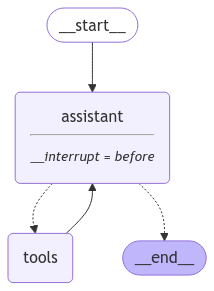

In [17]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "assistant")

memory = MemorySaver()

## human in the loop
graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

# Show
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
## human in the loop
## interupt befire, interupt_after  

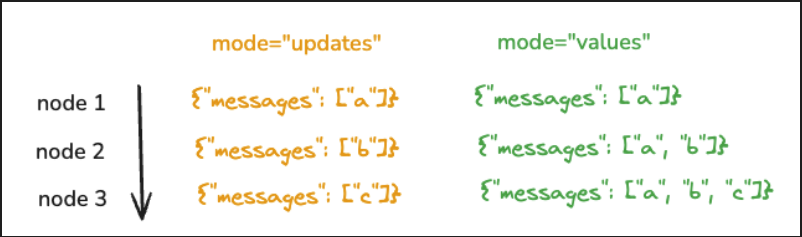

In [19]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread={"configurable":{"thread_id":"1"}}


In [20]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [21]:
state=graph.get_state(thread)
state.next

('assistant',)

In [22]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='839ec05f-745b-40f8-b745-48e1e4fcb147')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1eff1d36-780d-6feb-8000-dcace6cf37a3'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': '1', 'step': 0, 'parents': {}}, created_at='2025-02-23T10:46:14.866737+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1eff1d36-77fc-6a7e-bfff-704f779594df'}}, tasks=(PregelTask(id='7b41b920-f7a8-9ef6-c2a1-88a31ee618b8', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),))

In [23]:
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_wge7)
 Call ID: call_wge7
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [24]:
graph.update_state(thread,{"messages":[HumanMessage(content="No, actually multiply 15 and 5!")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1eff1d39-746d-6f10-8003-efd84d273fbe'}}

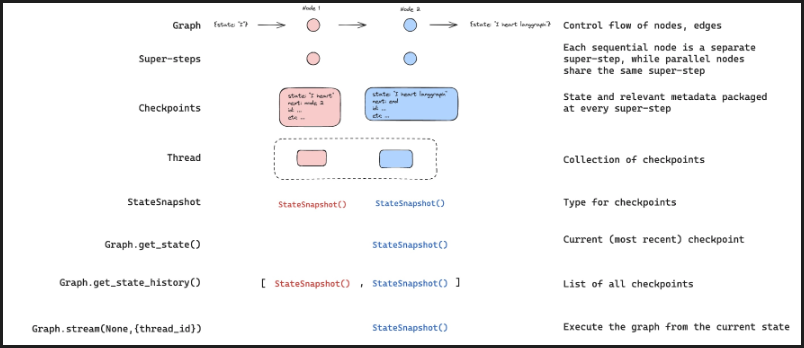

In [25]:
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, actually multiply 15 and 5!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_ewd4)
 Call ID: call_ewd4
  Args:
    a: 15
    b: 5
================================= Tool Message =================================
Name: multiply

75


In [26]:
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

75
================================== Ai Message ==================================

So the result of multiplying 15 and 5 is 75.


# Personal Assitant